# Reinforcement Learning Taxi Challenge

Well implement a classic reinforcement learning problem and solve it using Q learning.

The Taxi-v3 environment simulates a 5×5 grid world with four designated pick-up and drop-off locations. 

The goal is for a taxi agent to pick up a passenger at one location and drop them off at the correct destination. Each episode begins with random initial positions for the taxi, the passenger, and the destination.

The challenge is to train an agent using Q-Learning to complete trips efficiently—minimizing the number of steps and maximizing the total accumulated reward.

- Exercise Objectives
Reduce the average number of steps per trip.

Maximize the average reward per episode.

Achieve a stable policy with minimal illegal actions (e.g., invalid pickups/drop-offs).

Ensure convergence and generalization across randomized starting conditions.

# Environment 

We'll use the gymnasium environment. There are four designated pick-up and drop-off locations (Red, Green, Yellow and Blue) in the 5x5 grid world. The taxi starts off at a random square and the passenger at one of the designated locations.

Its an episodic learning problem: The goal is move the taxi to the passenger’s location, pick up the passenger, move to the passenger’s desired destination, and drop off the passenger. Once the passenger is dropped off, the episode ends.

Action Space: Discrete(6)
- 0: Move south (down)
- 1: Move north (up)
- 2: Move east (right)
- 3: Move west (left)
- 4: Pickup passenger
- 5: Drop off passenger

Observation Space:Discrete(500), a composite for:
- The 25 taxi positions (5x5 grid)
- Passenger locations:
    - 0: Red
    - 1: Green
    - 2: Yellow
    - 3: Blue
    - 4: In taxi
- Destinations:
    - 0: Red
    - 1: Green
    - 2: Yellow
    - 3: Blue

An observation is returned as an int() that encodes the state as:
- ((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination

There are 404 states that can actually be reached during an episode, including the end.
- There are 300 posible initial states: 25 taxi positions (the perimeter), 4 passenger locations (without the taxi interior), and 3 destinations (without the passengers location)

- Rewards
    - -1 for each step unless another reward is triggered
    - +20 delivering a passenger
    - -10 pickup and drop off illegally
    - Crashing with walls derives in the time step penalty

- Implementation
    - Termination if the taxi drops off the passenger or some time step limit is reached (default 200)
    - step() and reset() return a dict with the keys:
        - p - transition probability for the state
        - action mask - if actions will cause a transition to a new state. (A wall will not cause an status change)
            -info["action_mask"] contains a np.ndarray for each of the actions specifying if the action will change the state.
    - To sample a modifying action, use action = env.action_space.sample(info["action_mask"]) Or with a Q-value based algorithm action = np.argmax(q_values[obs, np.where(info["action_mask"] == 1)[0]]).

- Environment arguments
    -is_raining=False: If True the cab will move in intended direction with probability of 80% else will move in either left or right of target direction with equal probability of 10% in both directions.
    -fickle_passenger=False: If true the passenger has a 30% chance of changing destinations when the cab has moved one square away from the passenger’s source location. Passenger fickleness only happens on the first pickup and successful movement. If the passenger is dropped off at the source location and picked up again, it is not triggered again.

In [20]:
import gymnasium as gym
#Start the env
env= gym.make("Taxi-v3")
# observation: what the agent can "see" - cart position, etc.
# info: extra debugging information (usually not needed for basic learning)
observation, info = env.reset(seed=42)
print(f"Starting observation: {observation}")
print( "additional infor", info)

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an action: 
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # terminated: True if agent failed
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episode_over = terminated or truncated

print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: 386
additional infor {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
Episode finished! Total reward: -857


In [45]:
print(f"Action space: {env.action_space}") 
print(f"Sample action: {env.action_space.sample()}")  
print(f"Observation space: {env.observation_space}") 
print(f"Sample observation: {env.observation_space.sample()}") 
print("Observation check", env.observation_space.contains(499))

Action space: Discrete(6)
Sample action: 4
Observation space: Discrete(500)
Sample observation: 208
Observation check True


In [22]:
import gymnasium as gym
#Start the env
env= gym.make("Taxi-v3")
# observation: what the agent can "see" - cart position, etc.
# info: extra debugging information (usually not needed for basic learning)
observation, info = env.reset(seed=42)
print(f"Starting observation: {observation}")
print( "additional infor", info)

episode_over = False
total_reward = 0

for _ in range(1000):
    # Choose an action: 
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # terminated: True if agent failed
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    if terminated or truncated:
        observation, info = env.reset()

print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: 386
additional infor {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}
Episode finished! Total reward: -4069


In [1]:
import gymnasium as gym
import numpy as np

class TaxiDriver:
    def __init__(self, environment, step_size, discount, 
                 initial_epsilon, epsilon_decay, final_epsilon, initial_reward=0):
        """
        Initialize a Q-Learning agent.
        Args:
            environment: The training environment (already created with gym.make)
            step_size: Learning rate (alpha)
            discount: Discount factor (gamma)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode (0 < decay < 1)
            final_epsilon: Minimum exploration rate (e.g., 0.1)
            initial_reward: Initial Q-value (default 0)
        """
        self.env = environment
        self.step_size = step_size
        self.discount = discount
        self.epsilon = initial_epsilon
        self.decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.q_table = self.initiate_q_table(initial_reward)
        self.reward = []     
        self.length = []     
        self.training_error = []   
        
        
    def initiate_q_table(self, initial_reward):
        Q_table = {}
        for state in range(self.env.observation_space.n):
            Q_table[state] = np.full(self.env.action_space.n, initial_reward)
        return Q_table

    def get_action(self, observation):
        if np.random.uniform() > self.epsilon:
            # Exploitation (greedy)
            return np.argmax(self.q_table[observation])
        else:
            # Exploration
            return self.env.action_space.sample()

    def update_q(self, observation, action, reward, terminated, next_observation):
        #Bellman equation: given a state s, and taking a certain action a, whats
        # the value (expected rewards) from the state i arrive with a.
        #The value of a state, under optimal policy, should be equal to the expected return
        #for the best action from that state
        
        best_next = np.max(self.q_table[next_observation]) * (not terminated)
        td_target = reward + self.discount * best_next
        td_error = td_target - self.q_table[observation][action]
        self.q_table[observation][action] += self.step_size * td_error
        self.training_error.append(abs(td_error))

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon * self.decay)


In [35]:
# Training hyperparameters
step_size = 0.01        # How fast to learn (higher = faster but less stable)
n_episodes = 200000        # Number of hands to practice
initial_epsilon = 1.0         # Start with random actions
epsilon_decay =initial_epsilon /(n_episodes/2)  # Reduce exploration over time
final_epsilon = 0.1       # Always keep some exploration
discount=0.95
initial_reward =0.2
# Create environment and agent
env = gym.make("Taxi-v3")

agent= TaxiDriver(env, step_size=step_size, discount=discount,
                   initial_epsilon=initial_epsilon, epsilon_decay=epsilon_decay,
                   final_epsilon=final_epsilon, initial_reward=initial_reward)

In [36]:
from tqdm import tqdm  # Progress bar

for episode in tqdm(range(n_episodes)):
    # Start a new hand
    obs, info = env.reset()
    total_reward = 0
    steps = 0
    done = False

    # Play one complete hand
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(obs)

        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Learn from this experience
        agent.update_q(obs, action, reward, terminated, next_obs)

        total_reward += reward
        # Move to next state
        done = terminated or truncated
        obs = next_obs
        steps += 1

    # Reduce exploration rate (agent becomes less random over time)
    agent.reward.append(total_reward)
    agent.length.append(steps)
    agent.decay_epsilon()

100%|██████████| 200000/200000 [01:23<00:00, 2403.48it/s]


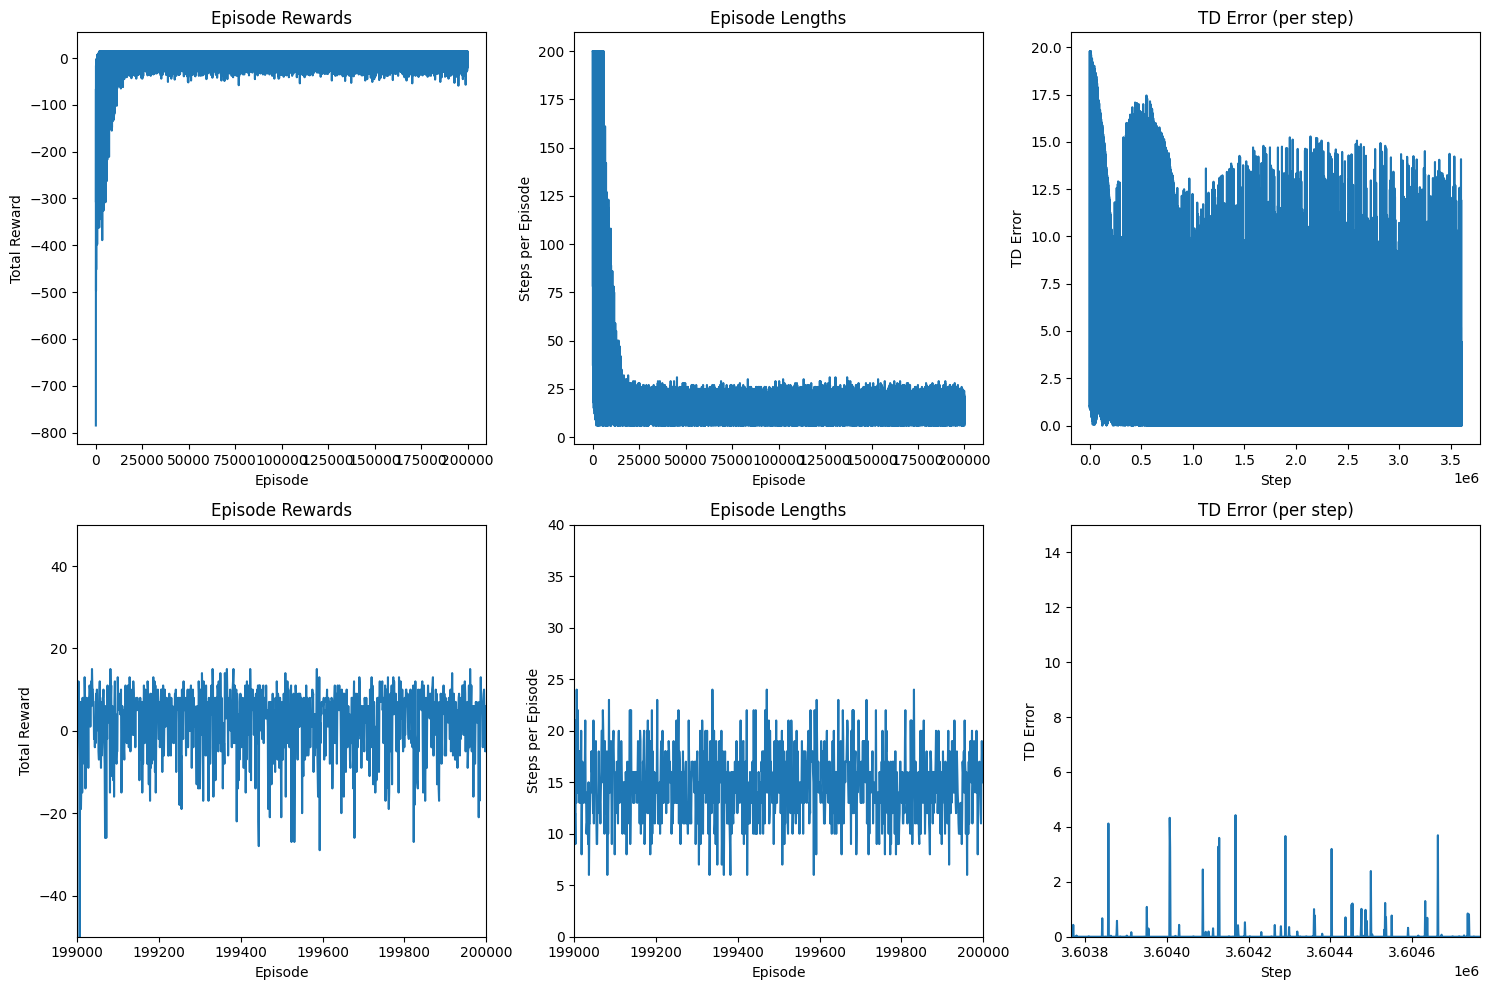

In [38]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10),sharex=False)

# Episodic rewards
axs[0,0].set_title("Episode Rewards")
axs[0,0].plot(agent.reward)
axs[0,0].set_ylabel("Total Reward")
axs[0,0].set_xlabel("Episode")

# Episode lengths
axs[0,1].set_title("Episode Lengths")
axs[0,1].plot(agent.length)
axs[0,1].set_ylabel("Steps per Episode")
axs[0,1].set_xlabel("Episode")

# Temporal Difference Error
axs[0,2].set_title("TD Error (per step)")
axs[0,2].plot(agent.training_error)
axs[0,2].set_ylabel("TD Error")
axs[0,2].set_xlabel("Step")


# Episodic rewards
axs[1,0].set_title("Episode Rewards")
axs[1,0].plot(agent.reward)
axs[1,0].set_ylabel("Total Reward")
axs[1,0].set_xlabel("Episode")
axs[1,0].set_xlim(len(agent.reward)-1000,len(agent.reward))
axs[1,0].set_ylim(-50,+50)

# Episode lengths
axs[1,1].set_title("Episode Lengths")
axs[1,1].plot(agent.length)
axs[1,1].set_ylabel("Steps per Episode")
axs[1,1].set_xlabel("Episode")
axs[1,1].set_xlim(len(agent.length)-1000,len(agent.length))
axs[1,1].set_ylim(0,40)

# Temporal Difference Error
axs[1,2].set_title("TD Error (per step)")
axs[1,2].plot(agent.training_error)
axs[1,2].set_ylabel("TD Error")
axs[1,2].set_xlabel("Step")
axs[1,2].set_xlim(len(agent.training_error)-1000,len(agent.training_error))
axs[1,2].set_ylim(0,15)

plt.tight_layout()
plt.show()


# Evaluation and test

With the training complete, we turn to evaluating its performance

In [46]:
# Test the trained agent
def test_agent(agent, env, num_episodes=10000):
    """Test agent performance without learning or exploration."""
    total_rewards = []
    steps = []
    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False
        steps_=0
        while not done:
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            steps_ +=1
            done = terminated or truncated
            
        steps.append(steps_)
        total_rewards.append(episode_reward)

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0) #if reward positive then succesful dropoff
    #negative reward would mean to many steps
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate (succesfull dropoff): {win_rate}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")
    print(f"average episode duration: {np.mean(steps):.3f}")
# Test your agent
test_agent(agent, env)

Test Results over 10000 episodes:
Win Rate (succesfull dropoff): 1.0
Average Reward: 7.908
Standard Deviation: 2.599
average episode duration: 13.092
